In [1]:
import os

# --- Path setup: works in Colab AND locally ---
try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_ROOT = "/content/drive/MyDrive/nassau-shipping-analysis"
except ImportError:
    # Running locally – notebook is inside <project>/notebook/
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
    if not os.path.isdir(os.path.join(PROJECT_ROOT, "data")):
        PROJECT_ROOT = os.getcwd()  # fallback: running from project root

RAW_DIR       = os.path.join(PROJECT_ROOT, "data", "raw")
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "Processed")
REPORTS_DIR   = os.path.join(PROJECT_ROOT, "reports")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data dir: {RAW_DIR}")
print(f"Processed dir: {PROCESSED_DIR}")

Project root: /Users/tulikasingh/Desktop/nassau-shipping-analysis
Raw data dir: /Users/tulikasingh/Desktop/nassau-shipping-analysis/data/raw
Processed dir: /Users/tulikasingh/Desktop/nassau-shipping-analysis/data/Processed


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(os.path.join(RAW_DIR, "nassau_distributor.csv"))

In [4]:
df.sample(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
5358,5359,US-2023-107328-CHO-SCR-58000,08-08-2025,04-02-2029,Standard Class,107328,United States,Los Angeles,California,90036,Chocolate,Pacific,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,21.60,6,15.00,6.60
3085,3086,US-2022-104185-CHO-SCR-58000,03-09-2024,29-02-2028,Second Class,104185,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,3.60,1,2.50,1.10
7001,7002,US-2024-154102-CHO-MIL-31000,06-02-2025,05-08-2029,Standard Class,154102,United States,San Francisco,California,94109,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,16.25,5,10.55,5.70
4407,4408,US-2023-153269-CHO-NUT-13000,09-03-2025,01-09-2028,First Class,153269,United States,Andover,Massachusetts,1810,Chocolate,Atlantic,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,13.96,4,9.96,4.00
2324,2325,US-2022-159513-CHO-MIL-31000,02-04-2024,30-09-2027,Standard Class,159513,United States,Los Angeles,California,90049,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
2610,2611,US-2022-163923-OTH-KAZ-38000,30-05-2024,24-11-2027,Standard Class,163923,United States,Springfield,Virginia,22153,Other,Gulf,OTH-KAZ-38000,Kazookles,13.00,4,1.00,12.00
6171,6172,US-2023-132997-CHO-NUT-13000,07-11-2025,01-05-2029,First Class,132997,United States,Rochester,New York,14609,Chocolate,Atlantic,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
2912,2913,US-2022-147501-CHO-TRI-54000,02-08-2024,27-01-2028,Standard Class,147501,United States,Seattle,Washington,98105,Chocolate,Pacific,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
1713,1714,US-2021-119151-CHO-TRI-54000,25-11-2024,22-05-2027,Second Class,119151,United States,New York City,New York,10009,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,15.00,4,9.80,5.20
4392,4393,US-2023-137547-CHO-TRI-54000,07-03-2025,01-09-2028,Standard Class,137547,United States,Fort Worth,Texas,76106,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [5]:
df.dtypes

Row ID              int64
Order ID              str
Order Date            str
Ship Date             str
Ship Mode             str
Customer ID         int64
Country/Region        str
City                  str
State/Province        str
Postal Code           str
Division              str
Region                str
Product ID            str
Product Name          str
Sales             float64
Units               int64
Gross Profit      float64
Cost              float64
dtype: object

In [6]:
df.dtypes.unique()

array([dtype('int64'), <StringDtype(na_value=nan)>, dtype('float64')],
      dtype=object)

In [7]:
df.shape

(10194, 18)

In [8]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [9]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [10]:
for col in ['Ship Mode', 'Division', 'Region', 'Country/Region']:
    df[col].unique()

In [11]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
6759,6760,US-2023-116729-CHO-MIL-31000,25-12-2025,19-06-2029,First Class,116729,United States,Los Angeles,California,90049,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,22.75,7,14.77,7.98
2357,2358,US-2022-166492-CHO-SCR-58000,07-04-2024,01-10-2027,First Class,166492,United States,New York City,New York,10035,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
1270,1271,US-2021-108189-CHO-MIL-31000,02-10-2024,28-03-2027,First Class,108189,United States,Tempe,Arizona,85281,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
5404,5405,US-2023-167241-CHO-MIL-31000,15-08-2025,11-02-2029,Standard Class,167241,United States,Los Angeles,California,90004,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42
688,689,US-2021-121566-CHO-SCR-58000,30-06-2024,27-12-2026,Standard Class,121566,United States,New York City,New York,10011,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,3.60,1,2.50,1.10


In [12]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y', errors='coerce')

In [13]:
df['Order Date'].isnull().sum()

np.int64(0)

In [14]:
df['Ship Date'].isnull().sum()

np.int64(0)

In [15]:
## checking invalid dates

In [16]:
invalid_dates = df[df['Ship Date'] < df['Order Date']]

In [17]:
len(invalid_dates)

0

In [18]:
df = df[df['Ship Date'] >= df['Order Date']].copy()

In [19]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
2170,2171,US-2022-154900-CHO-MIL-31000,2024-02-25,2027-08-22,Standard Class,154900,United States,Leominster,Massachusetts,1453,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,3.25,1,2.11,1.14
3138,3139,US-2022-147242-CHO-SCR-58000,2024-09-10,2028-03-06,Standard Class,147242,United States,Revere,Massachusetts,2151,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
3888,3889,US-2022-118871-OTH-GUM-21000,2024-12-04,2028-05-31,Second Class,118871,United States,Los Angeles,California,90049,Other,Pacific,OTH-GUM-21000,Wonka Gum,6.25,5,3.25,3.00
6607,6608,US-2023-165330-CHO-NUT-13000,2025-12-11,2029-06-02,Same Day,165330,United States,Anaheim,California,92804,Chocolate,Pacific,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,24.43,7,17.43,7.00
3418,3419,US-2022-132388-CHO-MIL-31000,2024-10-10,2028-04-03,First Class,132388,United States,Santa Barbara,California,93101,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,9.75,3,6.33,3.42


In [20]:
## converting string to readable string format

In [21]:
text_cols = ['Ship Mode', 'Division', 'Region', 'State/Province', 'City', 'Country/Region']
for col in text_cols:
    df[col] = df[col].astype(str).str.strip().str.title()

In [22]:
df['Ship Mode'].unique()

<ArrowStringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str

In [23]:
ship_mode_map = {
    'Standard Class': 'Standard Class',
    'First Class': 'First Class',
    'Second Class': 'Second Class',
    'Same Day': 'Same Day'
}

In [24]:
df['Ship Mode'] = df['Ship Mode'].map(ship_mode_map)


In [25]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
705,706,US-2021-103317-OTH-KAZ-38000,2024-07-05,2026-12-29,First Class,103317,United States,Palm Coast,Florida,32137,Other,Gulf,OTH-KAZ-38000,Kazookles,16.25,5,1.25,15.00
5634,5635,US-2023-145240-CHO-MIL-31000,2025-09-06,2029-02-28,First Class,145240,United States,Houston,Texas,77070,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,3.25,1,2.11,1.14
583,584,US-2021-133270-CHO-SCR-58000,2024-06-06,2026-11-30,First Class,133270,United States,Rochester,New York,14609,Chocolate,Atlantic,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,7.20,2,5.00,2.20
9625,9626,US-2024-128300-CHO-MIL-31000,2025-11-24,2030-05-19,Second Class,128300,United States,Summerville,South Carolina,29483,Chocolate,Gulf,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26.00,8,16.88,9.12
6342,6343,US-2023-146157-CHO-FUD-51000,2025-11-21,2029-05-18,Standard Class,146157,United States,Chicago,Illinois,60610,Chocolate,Interior,CHO-FUD-51000,Wonka Bar - Fudge Mallows,3.60,1,2.40,1.20


In [26]:
df.duplicated().sum()

np.int64(0)

In [27]:
for col in ['Sales','Units','Gross Profit','Cost']:
  print(df[col].min(),
  df[col].max()),
  print((df[col]<0).sum())

1.25 260.0
0
1 14
0
0.25 130.0
0
0.6 130.0
0


In [28]:
df.shape

(10194, 18)

In [29]:
df['Product Name'].unique()

<ArrowStringArray>
[       'Wonka Bar - Milk Chocolate', 'Wonka Bar - Triple Dazzle Caramel',
 'Wonka Bar - Nutty Crunch Surprise',    'Wonka Bar -Scrumdiddlyumptious',
         'Wonka Bar - Fudge Mallows',                         'Wonka Gum',
                         'Kazookles',                'Lickable Wallpaper',
              'Fizzy Lifting Drinks',                       'Laffy Taffy',
                         'SweeTARTS',                             'Nerds',
                       'Hair Toffee',            'Everlasting Gobstopper',
                           'Fun Dip']
Length: 15, dtype: str

In [30]:
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], errors='coerce')

In [31]:
df['Shipping Lead Time']=(df['Ship Date']-df['Order Date']).dt.days
df.sample()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time
9741,9742,US-2024-144862-CHO-MIL-31000,2025-12-01,2030-05-28,Standard Class,144862,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-MIL-31000,Wonka Bar - Milk Chocolate,22.75,7,14.77,7.98,1639


In [32]:
df['Shipping Lead Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Shipping Lead Time, dtype: float64

In [33]:
print((df['Shipping Lead Time'] >= 0).sum())
print((df['Shipping Lead Time'] <= 365).sum())

10194
0


In [34]:
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time
4589,4590,US-2023-114622-CHO-FUD-51000,2025-04-10,2028-10-02,First Class,114622,United States,Springfield,Ohio,45503,Chocolate,Atlantic,CHO-FUD-51000,Wonka Bar - Fudge Mallows,7.20,2,4.80,2.40,1271
4017,4018,US-2022-157770-CHO-MIL-31000,2024-12-13,2028-06-06,First Class,157770,United States,Temecula,California,92592,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,3.25,1,2.11,1.14,1271
4452,4453,CA-2023-139675-CHO-MIL-31000,2025-03-13,2028-09-07,Second Class,139675,Canada,Calgary,Alberta,T2C,Chocolate,Pacific,CHO-MIL-31000,Wonka Bar - Milk Chocolate,26.00,8,16.88,9.12,1274
3045,3046,US-2022-168809-CHO-MIL-31000,2024-08-25,2028-02-15,Same Day,168809,United States,Houston,Texas,77041,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,3.25,1,2.11,1.14,1269
6980,6981,US-2024-164147-OTH-LIC-15000,2025-02-02,2029-07-28,First Class,164147,United States,Columbus,Ohio,43229,Other,Atlantic,OTH-LIC-15000,Lickable Wallpaper,180.00,9,90.00,90.00,1637


In [35]:
print(df.shape)

(10194, 19)


In [36]:
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order DayOfWeek'] = df['Order Date'].dt.day_name()
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Product Name,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek
9150,9151,US-2024-100356-CHO-MIL-31000,2025-10-21,2030-04-17,Standard Class,100356,United States,Chicago,Illinois,60653,...,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28,1639,2025,10,4,Tuesday
34,35,US-2021-115791-CHO-TRI-54000,2024-01-16,2026-07-11,Second Class,115791,United States,Philadelphia,Pennsylvania,19134,...,Wonka Bar - Triple Dazzle Caramel,22.50,6,14.70,7.80,907,2024,1,1,Tuesday
1582,1583,US-2021-127558-CHO-TRI-54000,2024-11-15,2027-05-11,First Class,127558,United States,Los Angeles,California,90008,...,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,907,2024,11,4,Friday
6683,6684,US-2023-145919-CHO-NUT-13000,2025-12-18,2029-06-14,Standard Class,145919,United States,Los Angeles,California,90032,...,Wonka Bar - Nutty Crunch Surprise,27.92,8,19.92,8.00,1274,2025,12,4,Thursday
1199,1200,US-2021-103191-CHO-TRI-54000,2024-09-22,2027-03-20,Standard Class,103191,United States,Chicago,Illinois,60653,...,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90,909,2024,9,3,Sunday


In [37]:
## from our last product name code

In [38]:
product_to_factory = {
    'Wonka Bar - Nutty Crunch Surprise': "Lot's O' Nuts",
    'Wonka Bar - Fudge Mallows': "Lot's O' Nuts",
    'Wonka Bar -Scrumdiddlyumptious': "Lot's O' Nuts",
    'Wonka Bar - Milk Chocolate': "Wicked Choccy's",
    'Wonka Bar - Triple Dazzle Caramel': "Wicked Choccy's",
    'Laffy Taffy': 'Sugar Shack',
    'SweeTARTS': 'Sugar Shack',
    'Nerds': 'Sugar Shack',
    'Fun Dip': 'Sugar Shack',
    'Fizzy Lifting Drinks': 'Sugar Shack',
    'Everlasting Gobstopper': 'Secret Factory',
    'Hair Toffee': 'The Other Factory',
    'Lickable Wallpaper': 'Secret Factory',
    'Wonka Gum': 'Secret Factory',
    'Kazookles': 'The Other Factory'
}

In [39]:
df['Factory'] = df['Product Name'].map(product_to_factory)
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Sales,Units,Gross Profit,Cost,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek,Factory
8053,8054,US-2024-100223-CHO-TRI-54000,2025-07-05,2029-12-31,Standard Class,100223,United States,Dallas,Texas,75220,...,11.25,3,7.35,3.90,1640,2025,7,3,Saturday,Wicked Choccy's
9237,9238,US-2024-127285-CHO-SCR-58000,2025-10-30,2030-04-29,Standard Class,127285,United States,Seattle,Washington,98115,...,7.20,2,5.00,2.20,1642,2025,10,4,Thursday,Lot's O' Nuts
7450,7451,US-2024-119655-CHO-MIL-31000,2025-04-20,2029-10-15,Standard Class,119655,United States,Detroit,Michigan,48234,...,13.00,4,8.44,4.56,1639,2025,4,2,Sunday,Wicked Choccy's
1121,1122,US-2021-113362-CHO-NUT-13000,2024-09-14,2027-03-12,Standard Class,113362,United States,Rochester,New York,14609,...,10.47,3,7.47,3.00,909,2024,9,3,Saturday,Lot's O' Nuts
6083,6084,US-2023-114972-CHO-MIL-31000,2025-11-03,2029-04-28,First Class,114972,United States,Los Angeles,California,90032,...,6.50,2,4.22,2.28,1272,2025,11,4,Monday,Wicked Choccy's


In [40]:
unmapped = df[df['Factory'].isnull()]['Product Name'].unique()
if len(unmapped) > 0:
    print(f"Warning: Unmapped products: {unmapped}")
    df['Factory'] = df['Factory'].fillna('Unknown')


In [41]:
#from given data

In [42]:
factory_coords = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.11914, -96.18115),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.1175, -89.971107)
}

In [43]:
df['Factory Latitude'] = df['Factory'].map(lambda x: factory_coords.get(x, (None, None))[0])
df['Factory Longitude'] = df['Factory'].map(lambda x: factory_coords.get(x, (None, None))[1])
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Gross Profit,Cost,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek,Factory,Factory Latitude,Factory Longitude
7865,7866,US-2024-120418-CHO-SCR-58000,2025-06-11,2029-12-03,First Class,120418,United States,Peoria,Arizona,85345,...,10.00,4.40,1636,2025,6,2,Wednesday,Lot's O' Nuts,32.881893,-111.768036
821,822,US-2021-169019-CHO-FUD-51000,2024-07-26,2027-01-20,Standard Class,169019,United States,San Antonio,Texas,78207,...,19.20,9.60,908,2024,7,3,Friday,Lot's O' Nuts,32.881893,-111.768036
272,273,US-2021-162089-CHO-MIL-31000,2024-03-30,2026-09-22,First Class,162089,United States,Brownsville,Texas,78521,...,14.77,7.98,906,2024,3,1,Saturday,Wicked Choccy's,32.076176,-81.088371
6037,6038,US-2023-116596-CHO-NUT-13000,2025-10-27,2029-04-22,Standard Class,116596,United States,New York City,New York,10011,...,34.86,14.00,1273,2025,10,4,Monday,Lot's O' Nuts,32.881893,-111.768036
7535,7536,US-2024-110198-CHO-NUT-13000,2025-05-01,2029-10-23,First Class,110198,United States,Coral Springs,Florida,33065,...,4.98,2.00,1636,2025,5,2,Thursday,Lot's O' Nuts,32.881893,-111.768036


In [44]:
df['Route_State'] = df['Factory'] + ' → ' + df['State/Province']
df['Route_Region'] = df['Factory'] + ' → ' + df['Region']
df.sample(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,...,Shipping Lead Time,Order Year,Order Month,Order Quarter,Order DayOfWeek,Factory,Factory Latitude,Factory Longitude,Route_State,Route_Region
6995,6996,US-2024-131282-CHO-SCR-58000,2025-02-05,2029-07-31,Second Class,131282,United States,Waco,Texas,76706,...,1637,2025,2,1,Wednesday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Texas,Lot's O' Nuts → Interior
4058,4059,US-2022-120161-CHO-TRI-54000,2024-12-18,2028-06-14,Standard Class,120161,United States,Springfield,Ohio,45503,...,1274,2024,12,4,Wednesday,Wicked Choccy's,32.076176,-81.088371,Wicked Choccy's → Ohio,Wicked Choccy's → Atlantic
6211,6212,US-2023-124506-CHO-SCR-58000,2025-11-11,2029-05-09,Standard Class,124506,United States,Chicago,Illinois,60623,...,1275,2025,11,4,Tuesday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Illinois,Lot's O' Nuts → Interior
4461,4462,US-2023-149272-CHO-NUT-13000,2025-03-15,2028-09-08,Standard Class,149272,United States,Bryan,Texas,77803,...,1273,2025,3,1,Saturday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Texas,Lot's O' Nuts → Interior
7057,7058,US-2024-105445-CHO-FUD-51000,2025-02-20,2029-08-17,Second Class,105445,United States,Louisville,Colorado,80027,...,1639,2025,2,1,Thursday,Lot's O' Nuts,32.881893,-111.768036,Lot's O' Nuts → Colorado,Lot's O' Nuts → Pacific


In [45]:
df['Region'].sample(5)

8802    Atlantic
1117        Gulf
804      Pacific
1683    Atlantic
1681     Pacific
Name: Region, dtype: str

In [46]:
df['Profit Margin %'] = (df['Gross Profit'] / df['Sales'] * 100).round(2)
df['Profit Margin %'].sample(5)

7061    64.92
3591    64.92
8883    71.35
9482    64.92
1659    52.00
Name: Profit Margin %, dtype: float64

In [47]:
print(df[['Factory', 'Shipping Lead Time', 'Route_State', 'Route_Region']].head())
print(f"\nTotal routes (factory → state): {df['Route_State'].nunique()}")
print(f"Total routes (factory → region): {df['Route_Region'].nunique()}")

           Factory  Shipping Lead Time                     Route_State  \
0  Wicked Choccy's                 909         Wicked Choccy's → Texas   
1  Wicked Choccy's                 909      Wicked Choccy's → Illinois   
2    Lot's O' Nuts                 909        Lot's O' Nuts → Illinois   
3    Lot's O' Nuts                 909        Lot's O' Nuts → Illinois   
4  Wicked Choccy's                 912  Wicked Choccy's → Pennsylvania   

                 Route_Region  
0  Wicked Choccy's → Interior  
1  Wicked Choccy's → Interior  
2    Lot's O' Nuts → Interior  
3    Lot's O' Nuts → Interior  
4  Wicked Choccy's → Atlantic  

Total routes (factory → state): 196
Total routes (factory → region): 20


In [48]:
df.to_csv(os.path.join(PROCESSED_DIR, "cleaned_data.csv"), index=False)
print(f"Saved cleaned data ({df.shape[0]} rows, {df.shape[1]} cols) to {PROCESSED_DIR}/cleaned_data.csv")

Saved cleaned data (10194 rows, 29 cols) to /Users/tulikasingh/Desktop/nassau-shipping-analysis/data/Processed/cleaned_data.csv


In [49]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

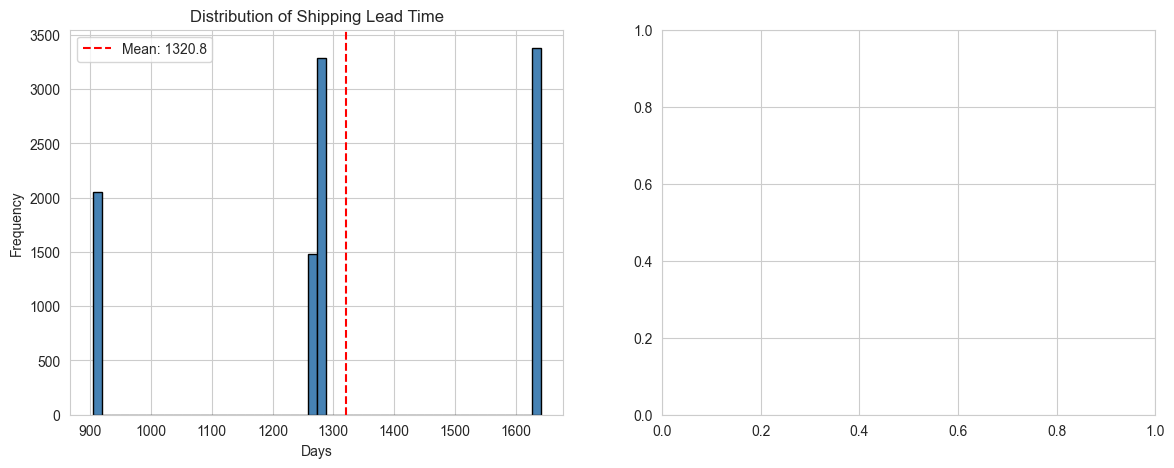

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Shipping Lead Time'], bins=50, edgecolor='black', color='steelblue')
axes[0].set_title('Distribution of Shipping Lead Time')
axes[0].set_xlabel('Days')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Shipping Lead Time'].mean(), color='red', linestyle='--', label=f"Mean: {df['Shipping Lead Time'].mean():.1f}")
axes[0].legend()

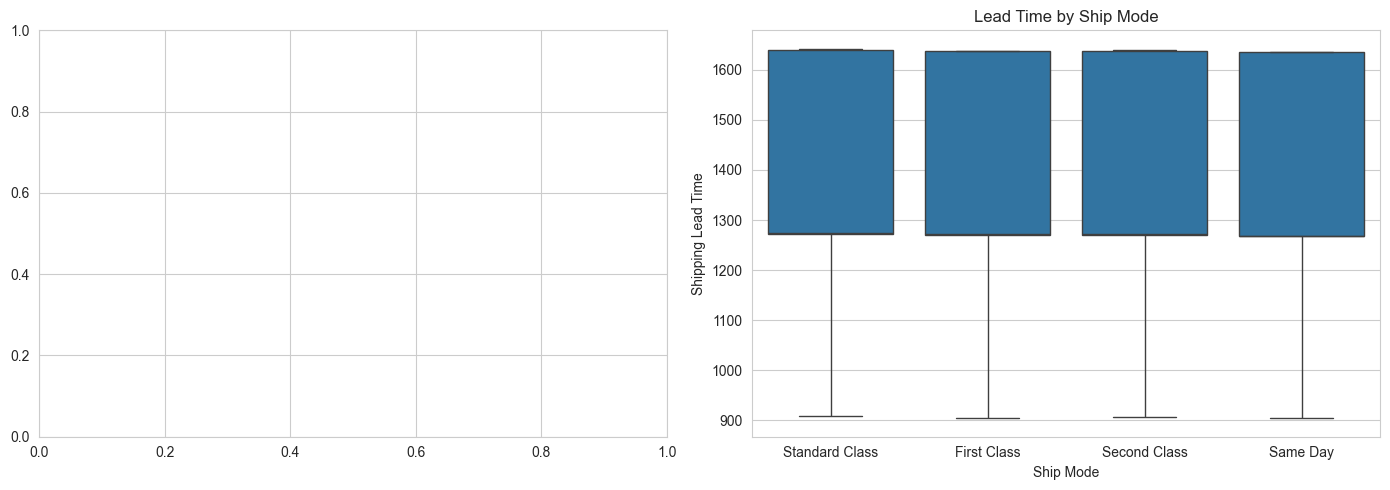

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(
    data=df,
    x="Ship Mode",
    y="Shipping Lead Time",
    ax=axes[1]
)

axes[1].set_title("Lead Time by Ship Mode")
axes[1].set_xlabel("Ship Mode")
axes[1].set_ylabel("Shipping Lead Time")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "eda_lead_time.png"), dpi=120, bbox_inches="tight")
plt.show()

Text(0, 0.5, 'Number of Orders')

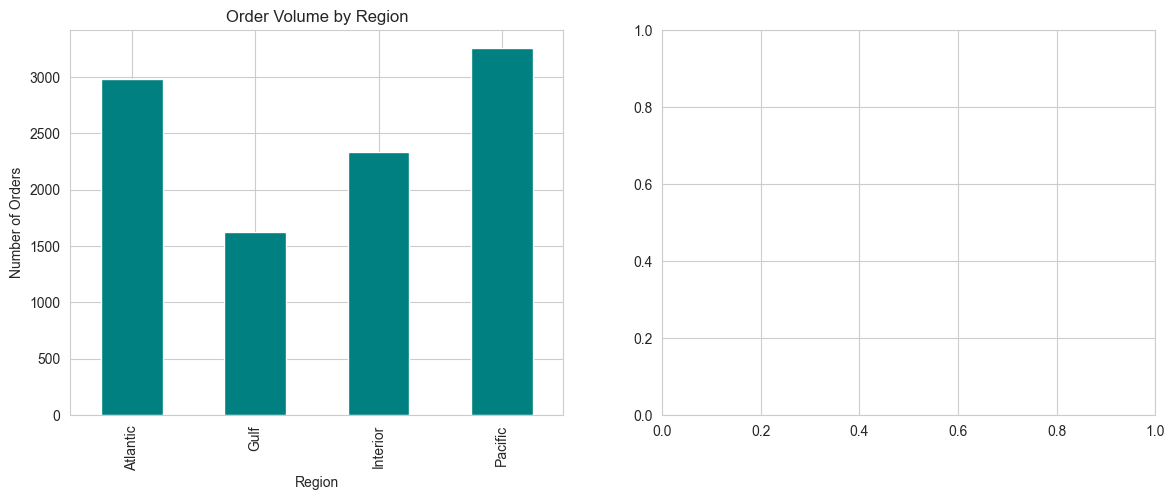

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('Region').size().plot(kind='bar', ax=axes[0], color='teal')
axes[0].set_title('Order Volume by Region')
axes[0].set_ylabel('Number of Orders')

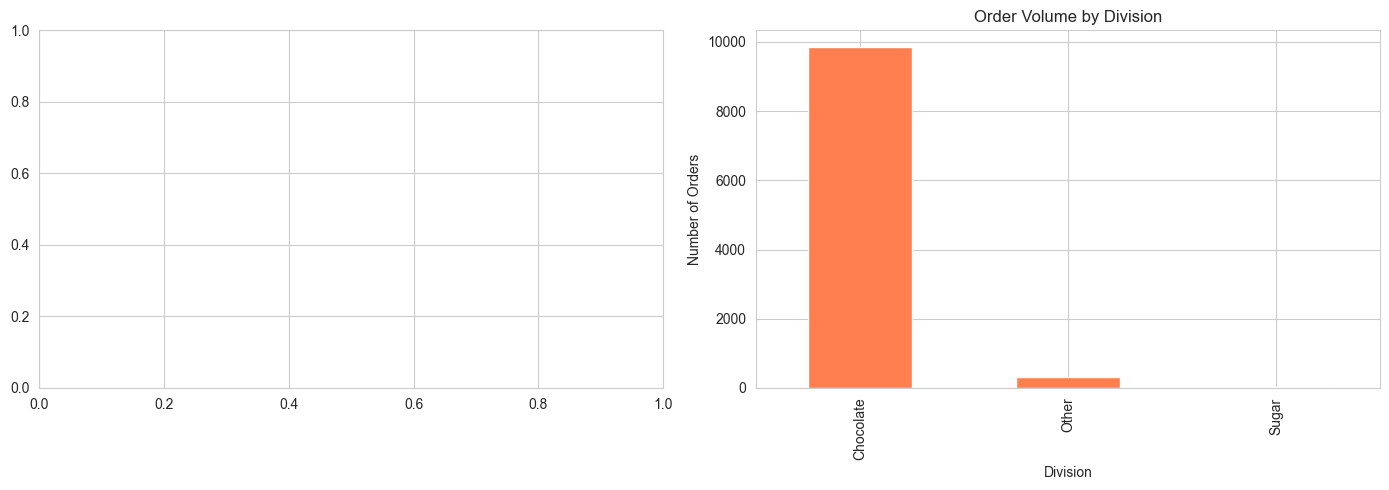

In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
df.groupby("Division").size().plot(
    kind="bar",
    ax=axes[1],
    color="coral"
)

axes[1].set_title("Order Volume by Division")
axes[1].set_xlabel("Division")
axes[1].set_ylabel("Number of Orders")

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "eda_volume.png"), dpi=120, bbox_inches="tight")
plt.show()

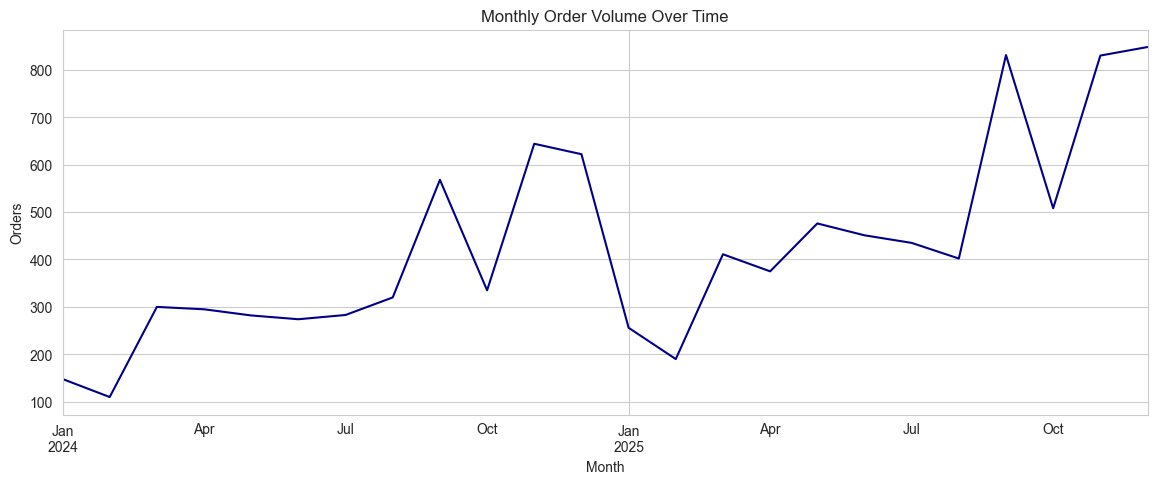

In [54]:
monthly_orders = df.set_index("Order Date").resample("ME").size()
plt.figure(figsize=(14, 5))
monthly_orders.plot(color="darkblue")
plt.title("Monthly Order Volume Over Time")
plt.xlabel("Month"); plt.ylabel("Orders")
plt.savefig(os.path.join(REPORTS_DIR, "eda_timeseries.png"), dpi=150, bbox_inches="tight")
plt.show()

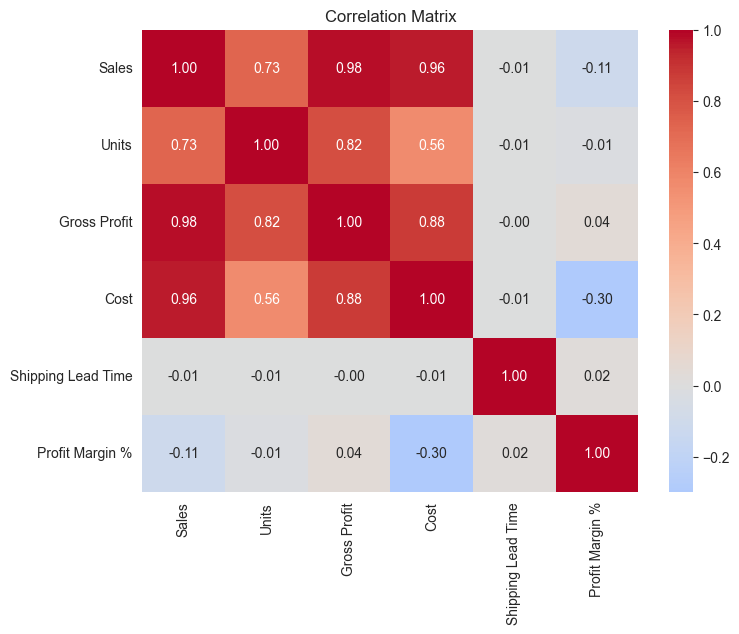

In [55]:
numeric_cols = ["Sales", "Units", "Gross Profit", "Cost", "Shipping Lead Time", "Profit Margin %"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation Matrix")
plt.savefig(os.path.join(REPORTS_DIR, "eda_correlation.png"), dpi=150, bbox_inches="tight")
plt.show()

In [56]:
print("=" * 60)
print("KEY EDA FINDINGS")
print("=" * 60)
print(f"Total orders: {len(df):,}")
print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Avg lead time: {df['Shipping Lead Time'].mean():.2f} days")
print(f"Median lead time: {df['Shipping Lead Time'].median():.2f} days")
print(f"\nLead time by Ship Mode:")
print(df.groupby('Ship Mode')['Shipping Lead Time'].agg(['mean', 'median', 'std']).round(2))
print(f"\nLead time by Region:")
print(df.groupby('Region')['Shipping Lead Time'].agg(['mean', 'median']).round(2))
print(f"\nLead time by Factory:")
print(df.groupby('Factory')['Shipping Lead Time'].agg(['mean', 'median', 'count']).round(2))

KEY EDA FINDINGS
Total orders: 10,194
Date range: 2024-01-02 to 2025-12-31
Avg lead time: 1320.84 days
Median lead time: 1274.00 days

Lead time by Ship Mode:
                   mean  median     std
Ship Mode                              
First Class     1338.28  1272.0  265.63
Same Day        1333.44  1269.0  253.81
Second Class    1323.85  1273.0  261.81
Standard Class  1314.33  1274.0  262.40

Lead time by Region:
             mean  median
Region                   
Atlantic  1322.75  1274.0
Gulf      1311.37  1274.0
Interior  1323.09  1274.0
Pacific   1322.19  1274.0

Lead time by Factory:
                      mean  median  count
Factory                                  
Lot's O' Nuts      1321.23  1274.0   5692
Secret Factory     1321.87  1274.0    217
Sugar Shack        1340.03  1274.0     33
The Other Factory  1280.28  1273.0    100
Wicked Choccy's    1321.08  1274.0   4152


In [57]:
state_perf = df.groupby('State/Province').agg(
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Volume=('Order ID', 'count'),
    Total_Sales=('Sales', 'sum'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).reset_index()

In [58]:
lead_time_threshold = state_perf['Avg_Lead_Time'].quantile(0.75)  # top 25% slowest
volume_threshold = state_perf['Volume'].quantile(0.75)  # top 25% by volume

In [59]:
state_perf['Is_Bottleneck'] = (
    (state_perf['Avg_Lead_Time'] >= lead_time_threshold) &
    (state_perf['Volume'] >= volume_threshold)
)

In [60]:
def perf_category(row):
    if row['Is_Bottleneck']:
        return 'Critical Bottleneck'
    elif row['Avg_Lead_Time'] >= lead_time_threshold:
        return 'Slow Route'
    elif row['Volume'] >= volume_threshold:
        return 'High-Volume Healthy'
    else:
        return 'Standard'

In [61]:
state_perf["Performance_Category"] = state_perf.apply(perf_category, axis=1)
state_perf = state_perf.round(2).sort_values("Avg_Lead_Time", ascending=False)
state_perf.to_csv(os.path.join(PROCESSED_DIR, "state_performance.csv"), index=False)
print(f"Saved state performance data ({len(state_perf)} states)")

Saved state performance data (59 states)


In [62]:
print("Critical Bottlenecks:")
print(state_perf[state_perf['Performance_Category'] =='Critical Bottleneck'])
print(f"\nTop 10 slowest states:")
print(state_perf.nlargest(10, 'Avg_Lead_Time')[['State/Province', 'Avg_Lead_Time', 'Volume']])

Critical Bottlenecks:
   State/Province  Avg_Lead_Time  Volume  Total_Sales  Avg_Profit_Margin  \
50      Tennessee        1391.49     183      2383.56              66.25   
55     Washington        1360.66     506      6921.15              66.52   

    Is_Bottleneck Performance_Category  
50           True  Critical Bottleneck  
55           True  Critical Bottleneck  

Top 10 slowest states:
          State/Province  Avg_Lead_Time  Volume
56         West Virginia        1638.00       4
37          North Dakota        1637.86       7
47          Saskatchewan        1457.00       2
20              Manitoba        1455.33      12
15                  Iowa        1443.90      30
33            New Mexico        1441.84      37
53               Vermont        1438.91      11
44  Prince Edward Island        1420.30      10
49          South Dakota        1395.92      12
50             Tennessee        1391.49     183


In [63]:
ship_mode_analysis = df.groupby('Ship Mode').agg(
    Volume=('Order ID', 'count'),
    Avg_Lead_Time=('Shipping Lead Time', 'mean'),
    Median_Lead_Time=('Shipping Lead Time', 'median'),
    Lead_Time_Std=('Shipping Lead Time', 'std'),
    Total_Sales=('Sales', 'sum'),
    Avg_Sales_Per_Order=('Sales', 'mean'),
    Avg_Profit_Margin=('Profit Margin %', 'mean')
).round(2).reset_index()



In [64]:
ship_mode_analysis["Volume_%"] = (ship_mode_analysis["Volume"] / ship_mode_analysis["Volume"].sum() * 100).round(2)
ship_mode_analysis = ship_mode_analysis.sort_values("Avg_Lead_Time")
ship_mode_analysis.to_csv(os.path.join(PROCESSED_DIR, "ship_mode_analysis.csv"), index=False)
print(ship_mode_analysis)

        Ship Mode  Volume  Avg_Lead_Time  Median_Lead_Time  Lead_Time_Std  \
3  Standard Class    6120        1314.33            1274.0         262.40   
2    Second Class    1979        1323.85            1273.0         261.81   
1        Same Day     547        1333.44            1269.0         253.81   
0     First Class    1548        1338.28            1272.0         265.63   

   Total_Sales  Avg_Sales_Per_Order  Avg_Profit_Margin  Volume_%  
3     85490.35                13.97              66.55     60.04  
2     27860.22                14.08              66.46     19.41  
1      7113.67                13.00              66.51      5.37  
0     21319.39                13.77              66.46     15.19  


In [65]:
ship_region = df.groupby(["Ship Mode", "Region"])["Shipping Lead Time"].mean().unstack().round(2)
print("\nLead time by Ship Mode × Region:")
print(ship_region)
ship_region.to_csv(os.path.join(PROCESSED_DIR, "ship_mode_region_pivot.csv"))


Lead time by Ship Mode × Region:
Region          Atlantic     Gulf  Interior  Pacific
Ship Mode                                           
First Class      1335.57  1319.82   1352.44  1340.94
Same Day         1296.82  1286.86   1397.23  1344.44
Second Class     1329.86  1324.72   1311.08  1327.54
Standard Class   1319.30  1306.93   1314.66  1313.23


## DAY 9 — Route Drill-Down Analysis

**Tasks**
1. Top 10 most efficient routes
2. Bottom 10 least efficient routes
3. Route variability analysis


In [66]:
import pandas as pd
import sys


In [67]:

sys.path.append('../src')
from kpi_calculator import compute_route_kpis, top_bottom_routes

In [68]:
df = pd.read_csv('../data/processed/cleaned_data.csv')
route_kpis = compute_route_kpis(df, 'Route_State')

In [69]:
top10, bottom10 = top_bottom_routes(route_kpis, n=10, min_volume=10)
print("=" * 70)
print("TOP 10 MOST EFFICIENT ROUTES")
print("=" * 70)
print(top10[['Route_State', 'Avg_Lead_Time', 'Route_Volume', 'Delay_Frequency_%', 'Route_Efficiency_Score']].to_string(index=False))

TOP 10 MOST EFFICIENT ROUTES
                     Route_State  Avg_Lead_Time  Route_Volume  Delay_Frequency_%  Route_Efficiency_Score
        Wicked Choccy's → Nevada        1182.25            12              100.0                   62.47
          Secret Factory → Texas        1227.06            16              100.0                   56.38
        Lot's O' Nuts → Virginia        1229.49           109              100.0                   56.05
Wicked Choccy's → South Carolina        1234.21            19              100.0                   55.41
            Lot's O' Nuts → Utah        1236.00            29              100.0                   55.16
      Wicked Choccy's → Virginia        1238.88           106              100.0                   54.77
   Wicked Choccy's → Mississippi        1240.45            22              100.0                   54.56
          Lot's O' Nuts → Nevada        1243.25            24              100.0                   54.18
        Wicked Choccy's → 

In [70]:
print("\n" + "=" * 70)
print("BOTTOM 10 LEAST EFFICIENT ROUTES")
print("=" * 70)
print(bottom10[['Route_State', 'Avg_Lead_Time', 'Route_Volume', 'Delay_Frequency_%', 'Route_Efficiency_Score']].to_string(index=False))

# 2. Most variable routes (highest std dev - unpredictable)
variable_routes = route_kpis[route_kpis['Route_Volume'] >= 10].nlargest(10, 'Lead_Time_Std')
print("\n" + "=" * 70)
print("MOST VARIABLE ROUTES (UNPREDICTABLE)")
print("=" * 70)
print(variable_routes[['Route_State', 'Avg_Lead_Time', 'Lead_Time_Std', 'Route_Volume']].to_string(index=False))

# Save reports
top10.to_csv('../data/processed/top10_routes.csv', index=False)
bottom10.to_csv('../data/processed/bottom10_routes.csv', index=False)
variable_routes.to_csv('../data/processed/variable_routes.csv', index=False)



BOTTOM 10 LEAST EFFICIENT ROUTES
                 Route_State  Avg_Lead_Time  Route_Volume  Delay_Frequency_%  Route_Efficiency_Score
Wicked Choccy's → New Mexico        1488.88            17              100.0                   20.80
        Lot's O' Nuts → Iowa        1479.00            16              100.0                   22.15
 Secret Factory → Washington        1472.36            11              100.0                   23.05
  Lot's O' Nuts → New Mexico        1456.94            18              100.0                   25.14
  Wicked Choccy's → Manitoba        1455.60            10              100.0                   25.33
 Lot's O' Nuts → Connecticut        1420.55            47              100.0                   30.09
      Wicked Choccy's → Iowa        1403.79            14              100.0                   32.37
   Wicked Choccy's → Indiana        1402.46            54              100.0                   32.55
 Wicked Choccy's → Tennessee        1393.76            67

In [ ]:
import sys; sys.path.append('../src')
import pandas as pd
from visualization import *


df = pd.read_csv('../data/processed/cleaned_data.csv')
route_kpis = pd.read_csv('../data/processed/route_state_kpis.csv')
state_perf = pd.read_csv('../data/processed/state_performance.csv')

# Test each plot
plot_lead_time_by_ship_mode(df).write_html('../reports/p1_ship_mode.html')
plot_route_efficiency_leaderboard(route_kpis).write_html('../reports/p2_leaderboard.html')
plot_volume_vs_leadtime(state_perf).write_html('../reports/p3_scatter.html')
plot_lead_time_trend(df).write_html('../reports/p4_trend.html')
plot_factory_performance(df).write_html('../reports/p5_factory.html')
plot_ship_mode_region_heatmap(df).write_html('../reports/p6_heatmap.html')
plot_us_choropleth(state_perf).write_html('../reports/p7_choropleth.html')
plot_route_network_map(df).write_html('../reports/p8_network.html')

print("✓ All 8 plots saved to reports/")